In [1]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [213]:
def visualize_pdb(pdb_file, output_file):
    """
    Visualize P, S, and nuc COM atoms inside a water box
    and draw a vertical line at x=53 nm.
    
    Parameters
    ----------
    pdb_file : str
        Path to the input PDB file
    output_file: str
        Path of the output figure
    """
    # Load PDB file
    u = mda.Universe(pdb_file)

    # Box dimensions in nm
    box_x, box_y, box_z = 106, 31.623, 31.623

    # Select COM atoms of residues
    P_atoms = u.select_atoms("resname P and name COM")
    S_atoms = u.select_atoms("resname S and name COM")
    nuc_atoms = u.select_atoms("resname nuc and name COM")

    # Extract coordinates (already in nm)
    coords_P = P_atoms.positions
    coords_S = S_atoms.positions
    coords_nuc = nuc_atoms.positions

    # Create 3D figure
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection="3d")

    # Set box dimensions
    ax.set_xlim([0, box_x])
    ax.set_ylim([0, box_y])
    ax.set_zlim([0, box_z])
    ax.set_xlabel("X (nm)")
    ax.set_ylabel("Y (nm)")
    ax.set_zlabel("Z (nm)")
    
    # Remove automatically generated frames
    ax.set_axis_off()

    # ✅ Draw straight line along x at y=z=mid
    mid_y, mid_z = box_y / 2, box_z / 2
    ax.plot([0, box_x], [mid_y, mid_y], [mid_z, mid_z], "tab:green", linewidth=2)

    # Plot residues with distinct markers
    ax.scatter(coords_P[:, 0], coords_P[:, 1], coords_P[:, 2],
               c="tab:orange", marker="o", s=100, label="P residues",
              edgecolor='brown')
    ax.scatter(coords_S[:, 0], coords_S[:, 1], coords_S[:, 2],
               c="magenta", marker="*", s=80, label="S residues", 
               edgecolor='purple')
    ax.scatter(coords_nuc[:, 0], coords_nuc[:, 1], coords_nuc[:, 2],
               c="black", marker="s", s=100, label="nuc residues")
    
    # ✅ Draw only the outer rectangle in the x–z plane
    ax.plot([0, box_x], [0, 0], [0, 0], "gray")              # bottom edge
    ax.plot([0, box_x], [box_y, box_y], [0, 0], "k-")
    ax.plot([0, box_x], [0, 0], [box_z, box_z], "gray")      # top edge
    ax.plot([0, box_x], [box_y, box_y], [box_z, box_z], "k-")
    ax.plot([0, 0], [0, 0], [0, box_z], "gray")              # left edge
    ax.plot([0, 0], [box_y, box_y], [0, box_z], "k-")
    ax.plot([0, 0], [0, box_y], [box_z, box_z], "gray")
    ax.plot([0, 0], [0, box_y], [0, 0], "gray")
    ax.plot([box_x, box_x], [0, 0], [0, box_z], "gray")      # right edge
    ax.plot([box_x, box_x], [box_y, box_y], [0, box_z], "k-")
    ax.plot([box_x, box_x], [0, box_y], [box_z, box_z], "gray")
    ax.plot([box_x, box_x], [0, box_y], [0, 0], "gray")
    
    # Add time step
    Timestep = u.trajectory.title[0].split()[-1]
    time = int(Timestep)*1e-6
    mantissa, exponent = f"{time:.1e}".split('e')
    ax.text(
        box_x/2.5, 0, box_z/20, 
        "$%s \\times 10^{%.0f}$ s"%(mantissa, int(exponent)), 
        fontsize=14, 
    )
    
    # ✅ Change viewpoint → look along y-axis
    ax.view_init(elev=0, azim=90)

    plt.tight_layout()
    plt.savefig(output_file)


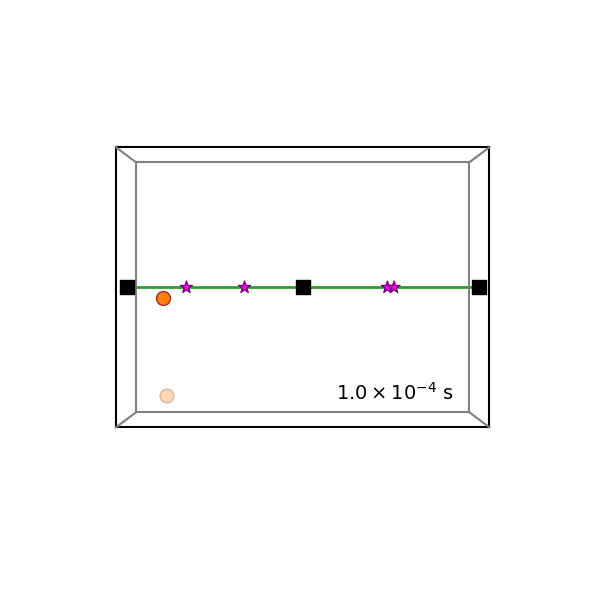

In [214]:
for i in range(1):
    visualize_pdb(
        f'./PDB_selected_twoSegments_kppE3.0kpnE1.0_1/{i}.pdb',
        f"./matplotlib_PDBPlots/{i}.png"
    )